## Libraries and Installation

In [ ]:
from google.colab import drive
drive.mount('/content/gdrive')
!ls /content/gdrive/MyDrive/deep_text/

Mounted at /content/gdrive
Pranav_LSTM2.ipynb  sherlockholmes.txt
Pranav_LSTM.ipynb   text_generation_sherlock_rnn_temp_exp.ipynb
RNNTorch.ipynb	    TokenLSTM.ipynb


In [ ]:
pip install pyspellchecker

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.2/7.2 MB 71.7 MB/s eta 0:00:00


In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import platform
import time
import pathlib
import os
import glob
from spellchecker import SpellChecker

print('Python version:', platform.python_version())
print('Tensorflow version:', tf.__version__)
print('Keras version:', tf.keras.__version__)

from collections import Counter
import tempfile
import re

Python version: 3.11.12
Tensorflow version: 2.18.0
Keras version: 3.8.0


## Data

In [ ]:
# TEMP_CHECKPOINT_DIR = os.path.join('/tmp', 'lstm_checkpoints')
# os.makedirs(TEMP_CHECKPOINT_DIR, exist_ok=True)
checkpoint_dir = 'tmp/checkpoints'
os.makedirs(checkpoint_dir, exist_ok=True)
print(f"Checkpoint directory created at: {checkpoint_dir}")
file_path = '/content/gdrive/MyDrive/deep_text/sherlockholmes.txt'
print(f"file path: {file_path}")

Checkpoint directory created at: tmp/checkpoints
file path: /content/gdrive/MyDrive/deep_text/sherlockholmes.txt


### Load Data

In [ ]:
with open(file_path, 'r', encoding='utf-8') as f:
    text = f.read()
print(f"data has been read successfully...")
print(f"Loaded {len(text)} characters.")

data has been read successfully...
Loaded 561801 characters.


### Data Exploration

In [ ]:
print(f"first 250 characters...")
print(f"{text[:250]}")

first 250 characters...
The Adventures of Sherlock Holmes

by Arthur Conan Doyle

I. A SCANDAL IN BOHEMIA


I.

To Sherlock Holmes she is always _the_ woman. I have seldom heard him
mention her under any other name. In his eyes she eclipses and
predominates the whole of her


### Data Preprocessing

In [ ]:
print(f"data preprocessing...")
char_set = set(text)

print(f"vocab(char_set) size: {len(char_set)}")
print()

# encode characters
chars_sorted = sorted(char_set)
char2int = {ch:i for i,ch in enumerate(chars_sorted)}

# decode characters
char_array = np.array(chars_sorted)

# encode text
print(f"encode text as vectors...")
text_encoded = np.array([char2int[ch] for ch in text], dtype=np.int32)
print(f"encoded text length: {len(text_encoded)}")
print()

# encoded text shape
print(f"encoded text shape: {text_encoded.shape}")
print()

# print out a few mappings
print(f"print out first few mappings...")
for i in text_encoded[:5]:
  print("{} -> {}".format(i, char_array[i]))
print()

# encoding characters
print(f"{text[:15]} ==> Encoded: {text_encoded[:15]}")
print()
print(f"{text_encoded[:15]} ==> Decoded: {''.join(char_array[text_encoded[:15]])}")

data preprocessing...
vocab(char_set) size: 89

encode text as vectors...
encoded text length: 561801

encoded text shape: (561801,)

print out first few mappings...
42 -> T
57 -> h
54 -> e
1 ->  
23 -> A

The Adventures  ==> Encoded: [42 57 54  1 23 53 71 54 63 69 70 67 54 68  1]

[42 57 54  1 23 53 71 54 63 69 70 67 54 68  1] ==> Decoded: The Adventures 


### Training Sequences

In [ ]:
print(f"define sentence length for a single input in characters")
sequence_length = 100
examples_per_epoch = len(text) // (sequence_length + 1)
print(f'examples_per_epoch: {examples_per_epoch}')

define sentence length for a single input in characters
examples_per_epoch: 5562


In [ ]:
print(f"create training dataset...")
char_dataset = tf.data.Dataset.from_tensor_slices(text_encoded)
for char in char_dataset.take(5):
    print(char_array[char.numpy()])

create training dataset...
T
h
e
 
A


In [ ]:
sequences = char_dataset.batch(sequence_length + 1, drop_remainder=True)
print('Sequences count: {}'.format(examples_per_epoch))
print()
for item in sequences.take(5):
  print(repr(''.join(char_array[item.numpy()])))

Sequences count: 5562

'The Adventures of Sherlock Holmes\n\nby Arthur Conan Doyle\n\nI. A SCANDAL IN BOHEMIA\n\n\nI.\n\nTo Sherlock H'
'olmes she is always _the_ woman. I have seldom heard him\nmention her under any other name. In his eye'
's she eclipses and\npredominates the whole of her sex. It was not that he felt any emotion\nakin to lov'
'e for Irene Adler. All emotions, and that one particularly,\nwere abhorrent to his cold, precise but a'
'dmirably balanced mind. He\nwas, I take it, the most perfect reasoning and observing machine that\nthe '


### Create Data Splits

In [ ]:
# basic split
total_chars = len(text_encoded)
train_end = int(total_chars * 0.8)
val_end = int(total_chars * 0.9)

# split text - 80, 10, 10
train_text = text_encoded[:train_end]
val_text = text_encoded[train_end:val_end]
test_text = text_encoded[val_end:]

def split_input_target(chunk):
  input_text = chunk[:-1]
  target_text = chunk[1:]
  return input_text, target_text

def create_dataset(ds, seq_length, batch_size, buffer_size):
  sequences = ds.batch(seq_length + 1, drop_remainder=True)
  dataset = sequences.map(split_input_target)
  dataset = dataset.shuffle(buffer_size).batch(batch_size, drop_remainder=True)

  return dataset

In [ ]:
# diverse split
def create_random_data(text_encoded, seq_length, num_examples, batch_size):
  last_start_indx = len(text_encoded) - seq_length - 1

  inputs = np.zeros((num_examples, seq_length), dtype=np.int32)
  targets = np.zeros((num_examples, seq_length), dtype=np.int32)

  # random start
  start_indices = np.random.randint(0, last_start_indx, size=num_examples)

  for i, start_indx in enumerate(start_indices):
    inputs[i] = text_encoded[start_indx:start_indx+seq_length]
    targets[i] = text_encoded[start_indx + 1:start_indx + seq_length + 1]

  dataset = tf.data.Dataset.from_tensor_slices((inputs, targets))
  dataset = dataset.shuffle(10000).batch(batch_size, drop_remainder=True)

  return dataset

In [ ]:
# basic split
BUFFER_SIZE = 10000
BATCH_SIZE = 64

# tensorflow datasets
train_dataset = tf.data.Dataset.from_tensor_slices(train_text)
val_dataset = tf.data.Dataset.from_tensor_slices(val_text)
test_dataset = tf.data.Dataset.from_tensor_slices(test_text)

train_dataset = create_dataset(train_dataset, sequence_length, BATCH_SIZE, BUFFER_SIZE)
val_dataset = create_dataset(val_dataset, sequence_length, BATCH_SIZE, BUFFER_SIZE)
test_dataset = create_dataset(test_dataset, sequence_length, BATCH_SIZE, BUFFER_SIZE)

print(f"train batch: {len(train_dataset)}")
print(f"valid batch: {len(val_dataset)}")
print(f"test batch: {len(test_dataset)}")

train batch: 69
valid batch: 8
test batch: 8


In [ ]:
# diverse split

# num_train_examples = 10000
# num_val_examples = 1000
# num_test_examples = 1000

# train_dataset = create_random_data(train_text, sequence_length, num_train_examples, BATCH_SIZE)
# val_dataset = create_random_data(val_text, sequence_length, num_val_examples, BATCH_SIZE)
# test_dataset = create_random_data(test_text, sequence_length, num_test_examples, BATCH_SIZE)

## Train Models

### One-Layer LSTM

In [ ]:
def build_One_Layer_LSTM(vocab_size, embedding_dim, rnn_units, batch_size):
  model = tf.keras.models.Sequential()

  # input layer
  model.add(tf.keras.layers.InputLayer(batch_input_shape=[batch_size, None]))

  # embedding layer
  model.add(tf.keras.layers.Embedding(
            input_dim=vocab_size,
            output_dim=embedding_dim
        ))

  # first lstm layer
  model.add(tf.keras.layers.LSTM(
            units=rnn_units,
            return_sequences=True,
            stateful=True,
            recurrent_initializer=tf.keras.initializers.GlorotNormal()
        ))

  # output layer
  model.add(tf.keras.layers.Dense(vocab_size))

  return model

### Two-Layer LSTM

In [ ]:
def build_Two_Layer_LSTM(vocab_size, embedding_dim, rnn_units, batch_size):
  model = tf.keras.models.Sequential()

  # input layer
  model.add(tf.keras.layers.InputLayer(batch_input_shape=[batch_size, None]))

  # embedding layer
  model.add(tf.keras.layers.Embedding(
            input_dim=vocab_size,
            output_dim=embedding_dim
        ))

  # first lstm layer
  model.add(  tf.keras.layers.LSTM(
            units=rnn_units,
            return_sequences=True,
            stateful=True,
            recurrent_initializer=tf.keras.initializers.GlorotNormal()
        ))

  # second lstm layer
  model.add(tf.keras.layers.LSTM(
            units=rnn_units,
            return_sequences=True,
            stateful=True,
            recurrent_initializer=tf.keras.initializers.GlorotNormal()
        ))

  # output layer
  model.add(tf.keras.layers.Dense(vocab_size))

  return model

### Build models

In [ ]:
vocab_size = len(char_set)
embedding_dim = 256
rnn_units = 1024
BATCH_SIZE = 64

In [ ]:
one_layer_lstm = build_One_Layer_LSTM(vocab_size, embedding_dim, rnn_units, BATCH_SIZE)
two_layer_lstm = build_Two_Layer_LSTM(vocab_size, embedding_dim, rnn_units, BATCH_SIZE)

In [ ]:
one_layer_lstm.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (64, None, 256)        │        22,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (64, None, 1024)       │     5,246,976 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (64, None, 89)         │        91,225 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,360,985 (20.45 MB)

 Trainable params: 5,360,985 (20.45 MB)

 Non-trainable params: 0 (0.00 B)

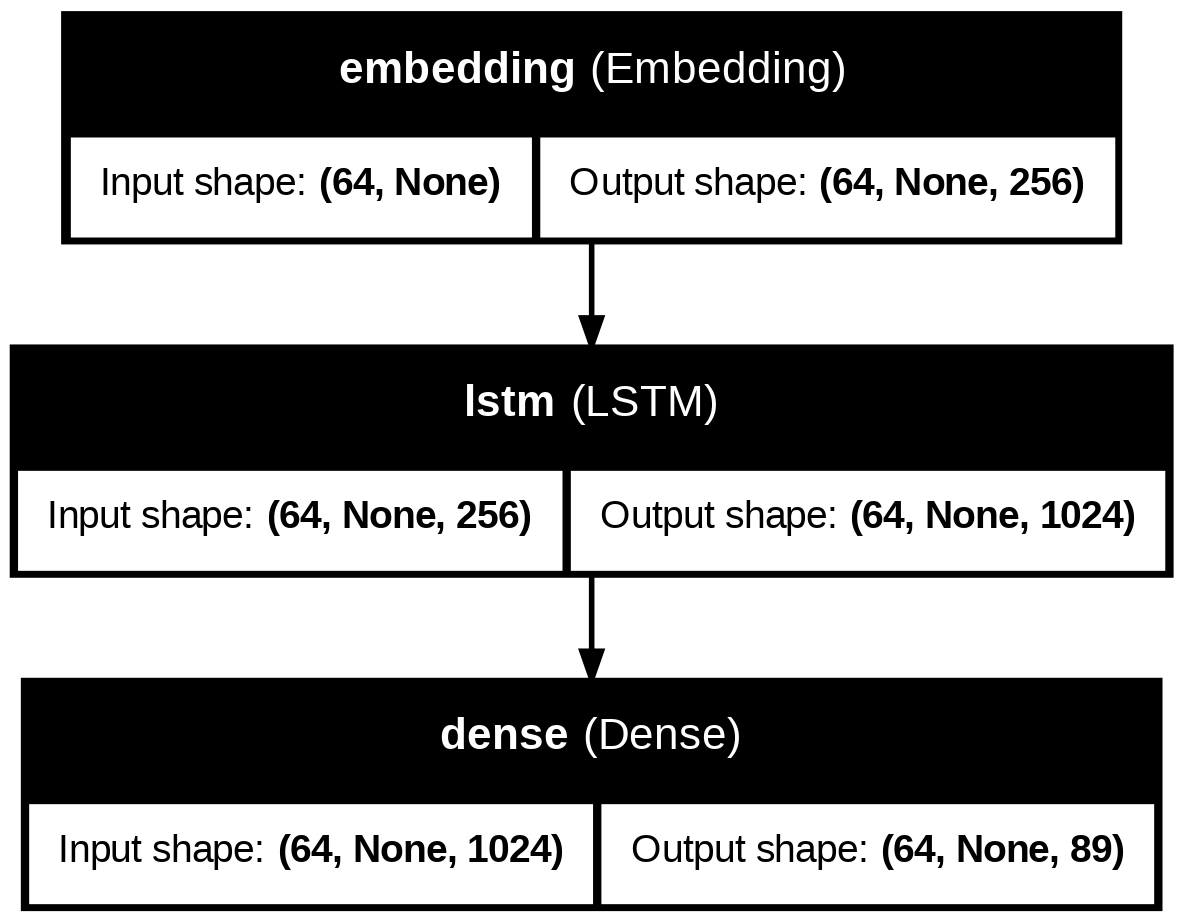

In [ ]:
tf.keras.utils.plot_model(
    one_layer_lstm,
    show_shapes=True,
    show_layer_names=True,
)

In [ ]:
two_layer_lstm.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (64, None, 256)        │        22,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (64, None, 1024)       │     5,246,976 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (64, None, 1024)       │     8,392,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (64, None, 89)         │        91,225 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,753,689 (52.47 MB)

 Trainable params: 13,753,689 (52.47 MB)

 Non-trainable params: 0 (0.00 B)

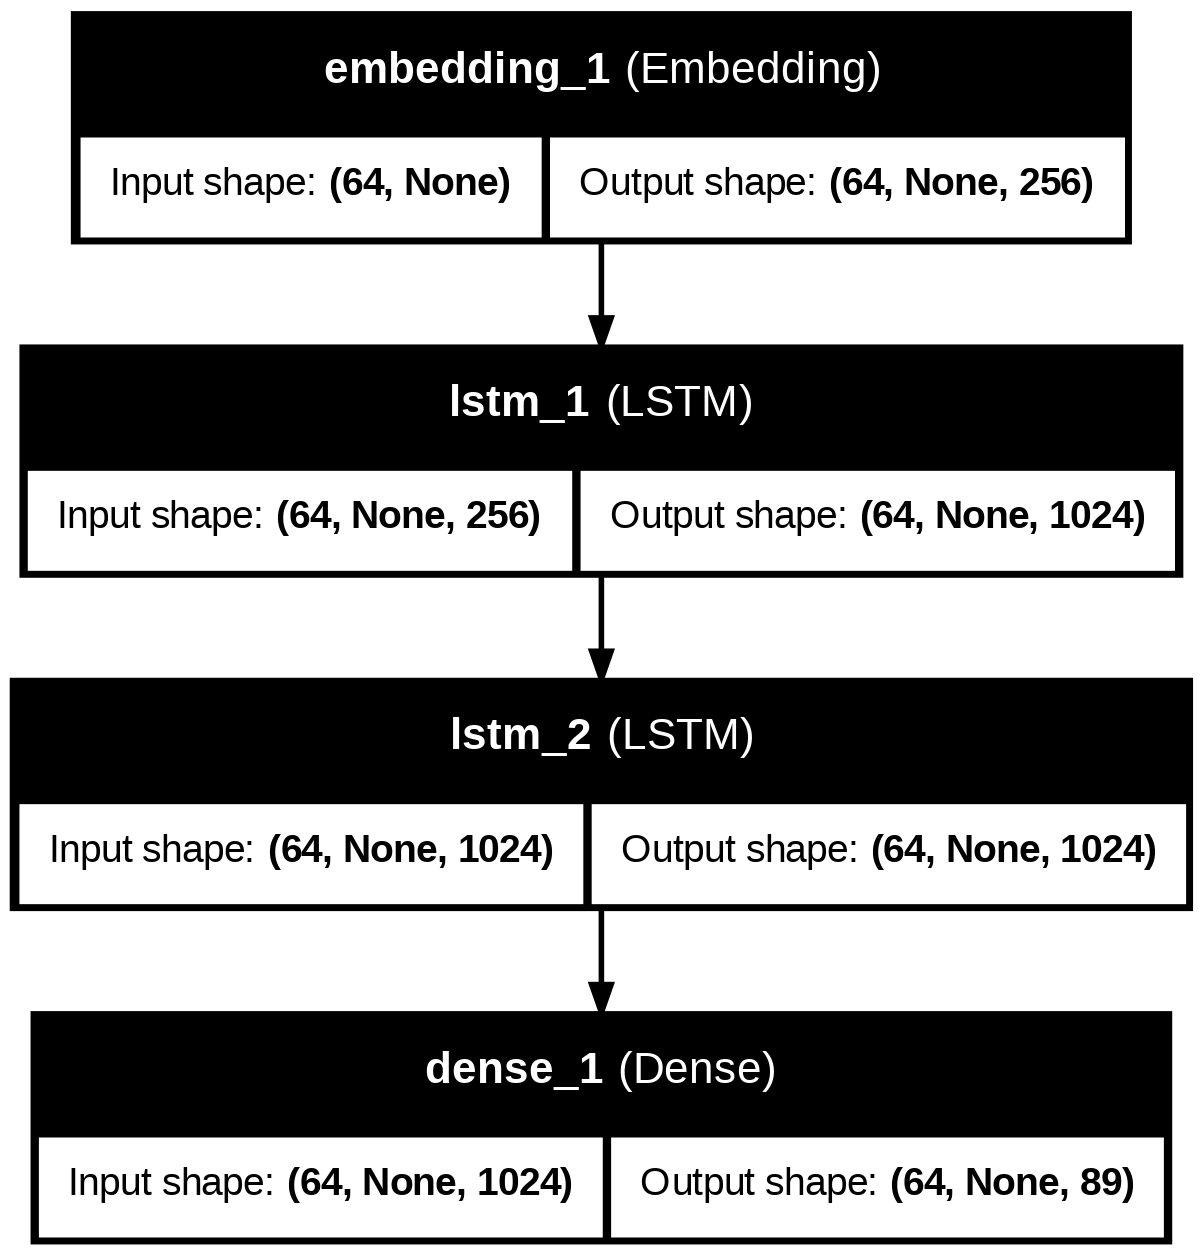

In [ ]:
tf.keras.utils.plot_model(
    two_layer_lstm,
    show_shapes=True,
    show_layer_names=True,
)

### Loss Function

In [ ]:
def loss(labels, logits):
    """
    Define the loss function for training.
    """
    return tf.keras.losses.sparse_categorical_crossentropy(
        y_true=labels,
        y_pred=logits,
        from_logits=True
    )

### Training Loop

In [ ]:
def train_model(model_build, model_name, vocab_size, embedding_dim, rnn_units,
                batch_size, train_dataset, val_dataset, epochs=40, lr=0.001):

  # build model
  model = model_build(vocab_size, embedding_dim, rnn_units, batch_size)

  # compile model
  optimizer = tf.keras.optimizers.Adam(learning_rate=lr)
  model.compile(
        optimizer=optimizer,
        loss=loss
    )

  model.summary()

  # save the model checkpoints
  model_checkpoint_dir = os.path.join(checkpoint_dir, model_name)
  os.makedirs(model_checkpoint_dir, exist_ok=True)
  print(f"Model checkpoints will be saved to: {model_checkpoint_dir}")
  checkpoint_prefix = os.path.join(model_checkpoint_dir, f'{model_name}_epoch_{{epoch:02d}}.weights.h5')

  # save best model
  checkpoint_cb = tf.keras.callbacks.ModelCheckpoint(
      filepath=checkpoint_prefix,
      save_best_only=True,
      save_weights_only=True,
      monitor='loss',
      mode='min',
      verbose=1
    )

  # early stopping to prevent overfitting
  early_stopping = tf.keras.callbacks.EarlyStopping(
        monitor='loss',
        patience=3,
        restore_best_weights=True
    )

  history = model.fit(
      x=train_dataset,
      epochs=epochs,
      validation_data=val_dataset,
      callbacks=[
          checkpoint_cb,
          early_stopping
        ]
    )

  # final model
  final_model_path = os.path.join(model_checkpoint_dir, f'{model_name}_final.weights.h5')
  model.save_weights(final_model_path)
  print(f"Final model weights saved to: {final_model_path}")

  return model, history, model_checkpoint_dir

In [ ]:
vocab_size = len(char_set)
embedding_dim = 256
rnn_units = 1024
batch_size = 64
epochs = 40
learning_rate = 0.001

In [ ]:
one_layer_model, one_layer_history, one_layer_checkpoint = train_model(
    build_One_Layer_LSTM,
    'One-Layer-LSTM',
    vocab_size,
    embedding_dim,
    rnn_units,
    batch_size,
    train_dataset,
    val_dataset,
    epochs=epochs,
    lr = learning_rate
)

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (64, None, 256)        │        22,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (64, None, 1024)       │     5,246,976 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (64, None, 89)         │        91,225 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,360,985 (20.45 MB)

 Trainable params: 5,360,985 (20.45 MB)

 Non-trainable params: 0 (0.00 B)

Model checkpoints will be saved to: tmp/checkpoints/One-Layer-LSTM
Epoch 1/40
67/69 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 3.2494
Epoch 1: loss improved from inf to 2.81766, saving model to tmp/checkpoints/One-Layer-LSTM/One-Layer-LSTM_epoch_01.weights.h5
69/69 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - loss: 3.2310 - val_loss: 2.3148
Epoch 2/40
67/69 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 2.2541
Epoch 2: loss improved from 2.81766 to 2.17122, saving model to tmp/checkpoints/One-Layer-LSTM/One-Layer-LSTM_epoch_02.weights.h5
69/69 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - loss: 2.2506 - val_loss: 1.9972
Epoch 3/40
67/69 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 1.9674
Epoch 3: loss improved from 2.17122 to 1.91784, saving model to tmp/checkpoints/One-Layer-LSTM/One-Layer-LSTM_epoch_03.weights.h5
69/69 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - loss: 1.9653 - val_loss: 1.7903
Epoch 4/40
67/69 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 1.7795
Epoch 4: loss improved from 1.91784 to 1.74858, saving model 

In [ ]:
two_layer_model, two_layer_history, two_layer_checkpoint = train_model(
    build_Two_Layer_LSTM,
    'Two-Layer-LSTM',
    vocab_size,
    embedding_dim,
    rnn_units,
    batch_size,
    train_dataset,
    val_dataset,
    epochs=epochs,
    lr = learning_rate
)

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ (64, None, 256)        │        22,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ (64, None, 1024)       │     5,246,976 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (64, None, 1024)       │     8,392,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (64, None, 89)         │        91,225 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,753,689 (52.47 MB)

 Trainable params: 13,753,689 (52.47 MB)

 Non-trainable params: 0 (0.00 B)

Model checkpoints will be saved to: tmp/checkpoints/Two-Layer-LSTM
Epoch 1/40
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 3.4321
Epoch 1: loss improved from inf to 3.08208, saving model to tmp/checkpoints/Two-Layer-LSTM/Two-Layer-LSTM_epoch_01.weights.h5
69/69 ━━━━━━━━━━━━━━━━━━━━ 6s 57ms/step - loss: 3.4271 - val_loss: 2.6655
Epoch 2/40
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 2.4920
Epoch 2: loss improved from 3.08208 to 2.34542, saving model to tmp/checkpoints/Two-Layer-LSTM/Two-Layer-LSTM_epoch_02.weights.h5
69/69 ━━━━━━━━━━━━━━━━━━━━ 4s 51ms/step - loss: 2.4899 - val_loss: 2.0942
Epoch 3/40
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 2.0572
Epoch 3: loss improved from 2.34542 to 1.99011, saving model to tmp/checkpoints/Two-Layer-LSTM/Two-Layer-LSTM_epoch_03.weights.h5
69/69 ━━━━━━━━━━━━━━━━━━━━ 4s 52ms/step - loss: 2.0562 - val_loss: 1.8315
Epoch 4/40
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 1.8055
Epoch 4: loss improved from 1.99011 to 1.76048, saving model 

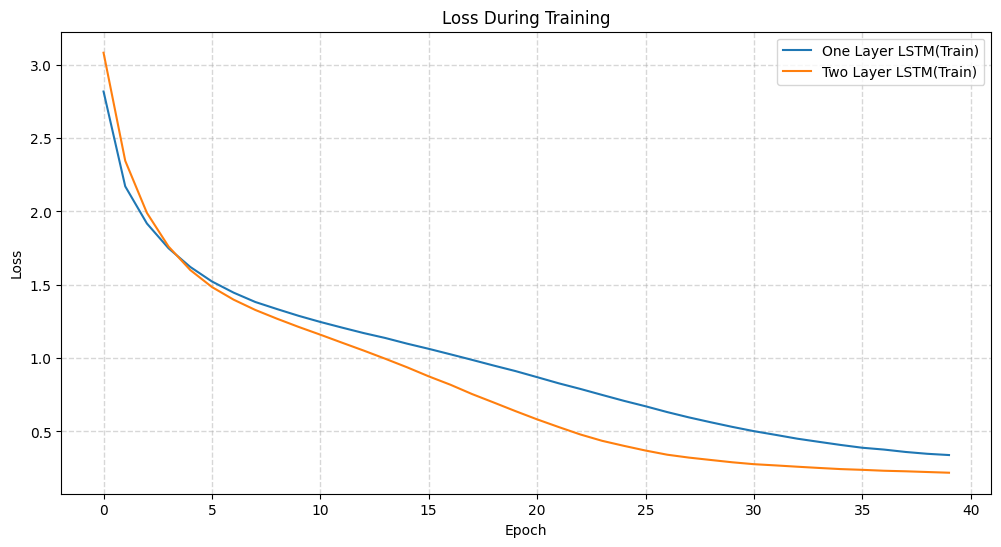

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(one_layer_history.history['loss'], label='One Layer LSTM(Train)')
plt.plot(two_layer_history.history['loss'], label='Two Layer LSTM(Train)')
plt.title('Loss During Training')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(linestyle='--', linewidth=1, alpha=0.5)

plt.savefig('lstm_training_loss.png', dpi=300, bbox_inches='tight')
plt.show()

## Evaluation

In [ ]:
def generate_text(model_name, start_text, generate_tokens=500, temperature=1.0):
    if model_name == 'One-Layer-LSTM':
        model = build_One_Layer_LSTM(len(char_set), embedding_dim, rnn_units, batch_size=1)
    else:
        model = build_Two_Layer_LSTM(len(char_set), embedding_dim, rnn_units, batch_size=1)

    # find checkpoint directory
    model_dir = os.path.join(checkpoint_dir, model_name)

    weight_files = glob.glob(os.path.join(model_dir, f'{model_name}_epoch_*.weights.h5'))
    if weight_files:
        latest = max(weight_files, key=os.path.getctime)
        model.load_weights(latest)
    else:
        print(f"No weights found in {model_dir}")
        return start_text

    model.build(tf.TensorShape([1, None]))

    input_indices = [char2int[char] for char in start_text]
    input_indices = tf.expand_dims(input_indices, 0)

    text_generated = []

    # reset states for RNN layers if they are stateful
    for layer in model.layers:
      if hasattr(layer, 'reset_states'):
        layer.reset_states()

    for _ in range(generate_tokens):
        predictions = model(input_indices)

        predictions = predictions / temperature

        # sample from the predictions
        predicted_id = tf.random.categorical(
            tf.expand_dims(predictions[0, -1, :], 0),
            num_samples=1
        )[0, 0].numpy()

        text_generated.append(char_array[predicted_id])

        # update input for next prediction
        input_indices = tf.expand_dims([predicted_id], 0)

    return start_text + ''.join(text_generated)

### One Layer LSTM - Temperature

In [ ]:
start_text = "Sherlock Holmes looked at me with a smile. "
temperatures = [0.1, 0.4, 0.7, 1.0]
print("One-Layer LSTM Text Generation varying Temperature:")
print("-" * 50)
for temp in temperatures:
  print(f"\nTemperature: {temp}")
  print("-" * 20)
  generated_text = generate_text(
      model_name='One-Layer-LSTM',
      start_text=start_text,
      generate_tokens=500,
      temperature=temp)
  print(generated_text)

One-Layer LSTM Text Generation varying Temperature:
--------------------------------------------------

Temperature: 0.1
--------------------
Sherlock Holmes looked at me with a smile. I am so
uncan, but it sounds funny, too, for he had a slight looking fire.

“There are three men waiting for him at the door,” said Holmes. “As to the letters, and it is still lay
in the deadly other times, entered when she complained of a
sound of remon voices, on the other side of the recondrs of the coroner’s jury.”

“It was a confession,” I ejaculated.

“No, for it was followed by a protruder. It was so dear to me that he was formerly a _danseuse_
at the Allegro, and that she has not seen he

Temperature: 0.4
--------------------
Sherlock Holmes looked at me with a smile. I am still with the
gentleman who had had a great hundred a ship. To me, for I knew one or two
things about him; so I made up my mind to go about the man’s face was only a
lad who is at we saw that my guitt had he remained forever a

### Two Layer LSTM - Temperature

In [ ]:
start_text = "Sherlock Holmes looked at me with a smile. "
temperatures = [0.1, 0.4, 0.7, 1.0]
print("Two-Layer LSTM Text Generation varying Temperature:")
print("-" * 50)
for temp in temperatures:
  print(f"\nTemperature: {temp}")
  print("-" * 20)
  generated_text = generate_text(
      model_name='Two-Layer-LSTM',
      start_text=start_text,
      generate_tokens=500,
      temperature=temp)
  print(generated_text)

Two-Layer LSTM Text Generation varying Temperature:
--------------------------------------------------

Temperature: 0.1
--------------------
Sherlock Holmes looked at me with a smile. I am convinced that the
inspector has formed the opinion upon the
matter.”

“Alas!” replied our visitor, “the very horror of my father. You may
returned my sister’s, and he would not go
to you, and so at last, as he would do nothing until then?”

“Nothing.”

“In that case I shall continue my professional round. But I shall be happy to give you an idea of an agent with which the light shone upon her dark dress I knew that it
was a rich material. She spoke a few centuries ago. It is true that I ha

Temperature: 0.4
--------------------
Sherlock Holmes looked at me with a smile. “I cannot say that it was during the night, sir, but it is not pleasant that the
matter was so delicate that I could not confide it that it is a police-station, which I might be a bachelor.”

“Nay, he was bringing home the goose as 

In [ ]:
def generate_text_nucleus(model_name, start_text, generate_tokens=1000, temperature=1.0, p=0.9):
    if model_name == 'One-Layer-LSTM':
        model = build_One_Layer_LSTM(len(char_set), embedding_dim, rnn_units, batch_size=1)
    else:
        model = build_Two_Layer_LSTM(len(char_set), embedding_dim, rnn_units, batch_size=1)

    # find checkpoint directory
    model_dir = os.path.join(checkpoint_dir, model_name)

    weight_files = glob.glob(os.path.join(model_dir, f'{model_name}_epoch_*.weights.h5'))
    if weight_files:
        latest = max(weight_files, key=os.path.getctime)
        # print(f"Loading weights from: {latest}")
        model.load_weights(latest)
    else:
        print(f"No weights found in {model_dir}")
        return start_text

    model.build(tf.TensorShape([1, None]))

    # convert text to vector
    input_indices = [char2int[char] for char in start_text]
    input_indices = tf.expand_dims(input_indices, 0)

    text_generated = []

    # reset states for RNN layers if they are stateful
    for layer in model.layers:
        if hasattr(layer, 'reset_states'):
            layer.reset_states()

    for _ in range(generate_tokens):
        predictions = model(input_indices)

        predictions = predictions / temperature

        pred = predictions[0, -1, :]

        # convert logits to probabilities
        probs = tf.nn.softmax(pred).numpy()

        # sort probabilities in descending order
        sorted_indices = np.argsort(-probs)
        sorted_probs = probs[sorted_indices]

        # calculate cumulative probability
        cumulative_probs = np.cumsum(sorted_probs)

        # find cutoff index where cumulative probability exceeds p
        cutoff_idx = np.argmax(cumulative_probs >= p)

        # include at least the top token if nothing exceeds threshold
        if cutoff_idx == 0 and cumulative_probs[0] < p:
            cutoff_idx = 1

        # get top p-tokens and probability
        top_indices = sorted_indices[:cutoff_idx+1]
        top_probs = sorted_probs[:cutoff_idx+1]

        # renormalize probability
        top_probs = top_probs / np.sum(top_probs)

        # sample from distribution
        predicted_id = np.random.choice(top_indices, size=1, p=top_probs)[0]

        # append
        text_generated.append(char_array[predicted_id])

        # update input for probability
        input_indices = tf.expand_dims([predicted_id], 0)

    return start_text + ''.join(text_generated)

### One Layer LSTM - Nucleus Sampling

In [ ]:
start_text = "Sherlock Holmes looked at me with a smile. "

nucleus_samples = [0.1, 0.45, 0.95]
print("One-Layer LSTM Text Generation varying Nucleus Sampling:")
print("-" * 50)
for nucleus in nucleus_samples:
  print(f"\nNucleus Sample: {nucleus}")
  print("-" * 20)
  generated_text = generate_text(
      model_name='One-Layer-LSTM',
      start_text=start_text,
      generate_tokens=500,
      temperature=0.7)
  print(generated_text)

One-Layer LSTM Text Generation varying Nucleus Sampling:
--------------------------------------------------

Nucleus Sample: 0.1
--------------------
Sherlock Holmes looked at me with a smile. “I am
afraid that I shall have a several of night more so than I can only deduce that this man Horner is innocent?”

“I cannot tell. It was only to-night. I know nothing for myself in my rely to d the third day after them as
far as on eny a singular man, fierce and quick ey from the hand to the room. I was too serious
country. Of course it was clear to me at the time, and it put me behind it, and that the same thing had come from
Paddington and were waiting in the heavy of me, and it has now dra

Nucleus Sample: 0.45
--------------------
Sherlock Holmes looked at me with a smile. I am still in the dark knee, and then suddenly tailing off for the
vacancies.’ His to himself and rubbed his long, nervous hands together in the same
with the evening of the man who had been no doubt seemed to see how th

### Two Layer LSTM - Nucleus Sampling

In [ ]:
nucleus_samples = [0.1, 0.45, 0.95]
print("Two-Layer LSTM Text Generation varying Nucleus Sampling:")
print("-" * 50)
for nucleus in nucleus_samples:
  print(f"\nNucleus Sample: {nucleus}")
  print("-" * 20)
  generated_text = generate_text(
      model_name='Two-Layer-LSTM',
      start_text=start_text,
      generate_tokens=500,
      temperature=0.7)
  print(generated_text)

Two-Layer LSTM Text Generation varying Nucleus Sampling:
--------------------------------------------------

Nucleus Sample: 0.1
--------------------
Sherlock Holmes looked at me with a smile. I am convinced to him as to the
vestry. Boon, he was little difficulty in entering the grounds, for unrepaired
breaches gaped in the old park wall. My profession has
brought a pack of cards in my pocket, and I
thought that, as we were a _partie carrée_, you might think,’ he answered. ‘You see it is really
confined to Londoners, and to grown a very
coarse one and was stamped with them without and started for
the market. All we were a night broaded.

“I will tell you that Miss Farou general street

Nucleus Sample: 0.45
--------------------
Sherlock Holmes looked at me with a smile. I am convinced that the
inspector has formed the opinion other methods. The bedroom window was a broad one and an excellent education.
I travelled in my youth, to bay my work as usual
at ten o’clock, but the green-room f

In [ ]:
def evaluate_spelling_accuracy(generated_text):

    # Initialize spell checker
    spell = SpellChecker(language='en')

    # Clean the text and split into words
    cleaned_text = re.sub(r'[^\w\s]', ' ', generated_text.lower())
    words = [word for word in cleaned_text.split() if word.strip()]

    words = [word for word in words if word.isalpha() and len(word) > 1]

    # Count total words
    total_words = len(words)

    if total_words == 0:
        return {
            "correct_words": 0,
            "incorrect_words": 0,
            "total_words": 0,
            "spelling_accuracy": 0.0,
            "most_common_incorrect": []
        }

    # Find misspelled words
    misspelled = spell.unknown(words)

    # Count correct words
    correct_words = total_words - len(misspelled)

    # Calculate spelling accuracy
    spelling_accuracy = (correct_words / total_words) * 100

    # Get most common incorrect words
    incorrect_counter = Counter(misspelled)
    most_common_incorrect = incorrect_counter.most_common(10)

    # Return metrics
    return {
        "correct_words": correct_words,
        "incorrect_words": len(misspelled),
        "total_words": total_words,
        "spelling_accuracy": spelling_accuracy,
        "most_common_incorrect": most_common_incorrect
    }

In [ ]:
def analyze_text(text, original_prompt_length):
    # Analyze only the generated portion
    generated_text = text[original_prompt_length:]

    # Word diversity (higher = more diverse vocabulary)
    words = re.findall(r'\b\w+\b', generated_text.lower())
    word_diversity = len(set(words)) / len(words) if words else 0

    # Repetition rate (higher = more repetition)
    word_counts = Counter(words)
    repetitions = sum(count - 1 for count in word_counts.values())
    repetition_rate = repetitions / len(words) if words else 0

    # Average sentence length
    sentences = re.split(r'[.!?]+', generated_text)
    sentences = [s for s in sentences if s.strip()]
    avg_sentence_length = sum(len(s.split()) for s in sentences) / len(sentences) if sentences else 0

    # Spelling accuracy
    spelling_accuracy = evaluate_spelling_accuracy(generated_text)['spelling_accuracy']

    return {
        "word_diversity": word_diversity,
        "repetition_rate": repetition_rate,
        "avg_sentence_length": avg_sentence_length,
        "spelling_accuracy" : spelling_accuracy
    }

## Complete Evaluation

In [ ]:
one_layer_regular_word_div = {}
one_layer_regular_spelling = {}
two_layer_regular_word_div = {}
two_layer_regular_spelling = {}

# For nucleus sampling with temp=0.2
one_layer_t20_word_div = {}
one_layer_t20_spelling = {}
two_layer_t20_word_div = {}
two_layer_t20_spelling = {}
# nucleus sampling with temp=0.7
one_layer_t70_word_div = {}
one_layer_t70_spelling = {}
two_layer_t70_word_div = {}
two_layer_t70_spelling = {}
# nucleus sampling with temp=1.3
one_layer_t13_word_div = {}
one_layer_t13_spelling = {}
two_layer_t13_word_div = {}
two_layer_t13_spelling = {}
# nucleus sampling with temp=2.0
one_layer_t20_word_div = {}
one_layer_t20_spelling = {}
two_layer_t20_word_div = {}
two_layer_t20_spelling = {}


# For nucleus sampling with p=0.95
one_layer_p95_word_div = {}
one_layer_p95_spelling = {}
two_layer_p95_word_div = {}
two_layer_p95_spelling = {}

# nucleus sampling with p=0.7
one_layer_p70_word_div = {}
one_layer_p70_spelling = {}
two_layer_p70_word_div = {}
two_layer_p70_spelling = {}

In [ ]:
print("\n===== SUMMARY OF RESULTS =====")
print(f"{'Model':<15} {'Sampling':<10} {'Temp':<6} {'Nucleus':<8} {'Word Div':<10} {'Spelling':<10}")
print("-" * 65)

nucleus_samples = [0.7, 0.8, 0.9, 0.95]
temperatures = [0.2, 0.5, 0.7, 1.0, 1.3, 1.7, 2.0]

results = []

# one layer lstm
for temp in temperatures:
  text = generate_text(
      model_name='One-Layer-LSTM',
      start_text=start_text,
      generate_tokens=500,
      temperature=temp
      )
  metrics = analyze_text(text, len(start_text))
  one_layer_regular_word_div[temp] = metrics['word_diversity']
  one_layer_regular_spelling[temp] = metrics['spelling_accuracy']

  print(f"{'One-Layer-LSTM':<15} {'Regular':<10} {temp:<6.1f} {'N/A':<8} "
          f"{metrics['word_diversity']:<10.3f} {metrics['spelling_accuracy']:<10.2f}")

  text = generate_text(
      model_name='Two-Layer-LSTM',
      start_text=start_text,
      generate_tokens=500,
      temperature=temp
      )
  metrics = analyze_text(text, len(start_text))
  two_layer_regular_word_div[temp] = metrics['word_diversity']
  two_layer_regular_spelling[temp] = metrics['spelling_accuracy']

  print(f"{'Two-Layer-LSTM':<15} {'Regular':<10} {temp:<6.1f} {'N/A':<8} "
  f"{metrics['word_diversity']:<10.3f} {metrics['spelling_accuracy']:<10.2f}")



===== SUMMARY OF RESULTS =====
Model           Sampling   Temp   Nucleus  Word Div   Spelling  
-----------------------------------------------------------------
One-Layer-LSTM  Regular    0.2    N/A      0.680      100.00    
Two-Layer-LSTM  Regular    0.2    N/A      0.779      98.89     
One-Layer-LSTM  Regular    0.5    N/A      0.636      98.94     
Two-Layer-LSTM  Regular    0.5    N/A      0.804      95.24     
One-Layer-LSTM  Regular    0.7    N/A      0.692      96.43     
Two-Layer-LSTM  Regular    0.7    N/A      0.793      96.63     
One-Layer-LSTM  Regular    1.0    N/A      0.755      90.32     
Two-Layer-LSTM  Regular    1.0    N/A      0.849      95.45     
One-Layer-LSTM  Regular    1.3    N/A      0.889      83.95     
Two-Layer-LSTM  Regular    1.3    N/A      0.796      84.88     
One-Layer-LSTM  Regular    1.7    N/A      0.815      78.82     
Two-Layer-LSTM  Regular    1.7    N/A      0.822      67.11     
One-Layer-LSTM  Regular    2.0    N/A      0.907      63.

In [ ]:
print("\n===== SUMMARY OF RESULTS =====")
print(f"{'Model':<15} {'Sampling':<10} {'Temp':<6} {'Nucleus':<8} {'Word Div':<10} {'Spelling':<10}")
print("-" * 65)
temperatures = [0.2, 0.5, 0.7, 1.0, 1.3, 1.7, 2.0]
nucleus_samples = [0.7, 0.8, 0.9, 0.95]

results = []

# one layer lstm
for temps in temperatures:
  for p in nucleus_samples:
    text = generate_text_nucleus(
        model_name='One-Layer-LSTM',
        start_text=start_text,
        generate_tokens=500,
        temperature=temps,
        p=p)
    metrics = analyze_text(text, len(start_text))
    if temps == 0.2:
      one_layer_t20_spelling[p] = metrics['spelling_accuracy']
      one_layer_t20_word_div[p] = metrics['word_diversity']

    if temps == 0.7:
      one_layer_t70_spelling[p] = metrics['spelling_accuracy']
      one_layer_t70_word_div[p] = metrics['word_diversity']

    if temps == 1.3:
      one_layer_t13_spelling[p] = metrics['spelling_accuracy']
      one_layer_t13_word_div[p] = metrics['word_diversity']

    if temps == 2.0:
      one_layer_t20_spelling[p] = metrics['spelling_accuracy']
      one_layer_t20_word_div[p] = metrics['word_diversity']

    if p == 0.7:
      one_layer_p70_spelling[temps] = metrics['spelling_accuracy']
      one_layer_p70_word_div = metrics['word_diversity']

    if p == 0.95:
      one_layer_p95_spelling[temps] = metrics['spelling_accuracy']
      one_layer_p95_word_div = metrics['word_diversity']

    print(f"{'One-Layer-LSTM':<15} {'Nucleus':<10} {temps:<6.1f} {p:<8} "
    f"{metrics['word_diversity']:<10.3f} {metrics['spelling_accuracy']:<10.2f}")

    text = generate_text_nucleus(
        model_name='Two-Layer-LSTM',
        start_text=start_text,
        generate_tokens=500,
        temperature=temps,
        p=p)

    metrics = analyze_text(text, len(start_text))

    if temps == 0.2:
      two_layer_t20_spelling[p] = metrics['spelling_accuracy']
      two_layer_t20_word_div[p] = metrics['word_diversity']

    if temps == 0.7:
      two_layer_t70_spelling[p] = metrics['spelling_accuracy']
      two_layer_t70_word_div[p] = metrics['word_diversity']

    if temps == 1.3:
      two_layer_t13_spelling[p] = metrics['spelling_accuracy']
      two_layer_t13_word_div[p] = metrics['word_diversity']

    if temps == 2.0:
      two_layer_t20_spelling[p] = metrics['spelling_accuracy']
      two_layer_t20_word_div[p] = metrics['word_diversity']

    if p == 0.7:
      two_layer_p70_spelling[temps] = metrics['spelling_accuracy']
      two_layer_p70_word_div = metrics['word_diversity']

    if p == 0.95:
      two_layer_p95_spelling[temps] = metrics['spelling_accuracy']
      two_layer_p95_word_div = metrics['word_diversity']

    print(f"{'Two-Layer-LSTM':<15} {'Nucleus':<10} {temps:<6.1f} {p:<8} "
    f"{metrics['word_diversity']:<10.3f} {metrics['spelling_accuracy']:<10.2f}")